In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import tukeylambda
import os


In [14]:
file_paths = [
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/mahalakshmi/Mahalakshmi1.1.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/mahalakshmi/Mahalakshmi1.2.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/mahalakshmi/Mahalakshmi1.3.csv"
]
# Check if files exist
for file in file_paths:
    if not os.path.exists(file):
        print(f"Error: {file} does not exist.")
        exit()

participant_name = os.path.basename(os.path.dirname(file_paths[-1])).capitalize()

df = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)

df['Key'] = df['Key'].astype(str)

correct_1_M = ((df["Tone"] == 1) & (df["Key"] == "M")).sum()
correct_2_C = ((df["Tone"] == 2) & (df["Key"] == "C")).sum()

total_1_M = (df["Tone"] == 1).sum()
total_2_C = (df["Tone"] == 2).sum()
total_count = len(df)

accuracy_1_M = (correct_1_M / total_1_M) * 100 if total_1_M > 0 else 0
accuracy_2_C = (correct_2_C / total_2_C) * 100 if total_2_C > 0 else 0

correct_count = correct_1_M + correct_2_C
incorrect_count = total_count - correct_count
overall_accuracy = (correct_count / total_count) * 100 if total_count > 0 else 0

print(f"Participant: {participant_name}")
print(f"In-tune correct: {correct_1_M} / {total_1_M} ({accuracy_1_M:.2f}%)")
print(f"Out-of-tune correct: {correct_2_C} / {total_2_C} ({accuracy_2_C:.2f}%)")
print(f"Correct responses: {correct_count}")
print(f"Incorrect responses: {incorrect_count}")
print(f"Overall accuracy: {overall_accuracy:.2f}%")

TypeError: data type 'Out-of-Tune: Reaction Time vs Gap (LOWESS Smoothing) Manaswini' not understood

In [ ]:
# Remove outliers based on RT range
df = df[(df['RT'] >= 199) & (df['RT'] <= 1000)].copy()

In [ ]:
df = df[(df["Tone"] == 1) & (df["Key"] == "M") | (df["Tone"] == 2) & (df["Key"] == "C")]

In [ ]:
# Create a new DataFrame with unique Gap values
MahaAve = pd.DataFrame({'Gap': df['Gap'].unique()})

# Compute mean RT for Tone == 1 and Tone == 2
MahaAve['InAveRT'] = MahaAve['Gap'].apply(lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 1), 'RT'].mean())
MahaAve['OutAveRT'] = MahaAve['Gap'].apply(lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 2), 'RT'].mean())

# Filter the dataframe based on Tone values
In = df[df['Tone'] == 1].copy()
Out = df[df['Tone'] == 2].copy()

# Create DataFrames with Gap and Reaction Time as columns
in_tune_df = pd.DataFrame({'Gap': MahaAve['Gap'], 'InAveRT': MahaAve['InAveRT']})
out_of_tune_df = pd.DataFrame({'Gap': MahaAve['Gap'], 'OutAveRT': MahaAve['OutAveRT']})

# Display results
print("In-Tune Average RT DataFrame:")
print(in_tune_df)

print("Out-of-Tune Average RT DataFrame:")
print(out_of_tune_df)


In-Tune Average RT DataFrame:
    Gap     InAveRT
0   330  492.000000
1   130  575.000000
2   190  732.000000
3    70  729.000000
4   180  741.666667
5   300  825.000000
6   340  696.000000
7    60  542.333333
8    80  770.000000
9   140  657.666667
10   50  774.000000
11  470  591.666667
12  170  666.000000
13  420  537.500000
14  280  562.000000
15  200  662.333333
16  250  638.333333
17  460  477.000000
18   90  612.500000
19  360  522.000000
20  320  614.500000
21  310  670.000000
22  110  653.000000
23  150  813.000000
24  100  536.500000
25  380  694.666667
26  400  570.000000
27  440  687.333333
28  160  731.000000
29  230  641.000000
30  500  623.500000
31  210  594.500000
32  270  638.500000
33  450  622.000000
34  350  575.000000
35  220  673.666667
36  430  654.000000
37  290  712.000000
38  260  514.000000
39  370  660.000000
40  490  708.500000
41  390  555.000000
42  480  647.000000
43  410  598.000000
44  240  653.000000
45  120  672.500000
Out-of-Tune Average RT DataFra

(46, 2) (46, 2)


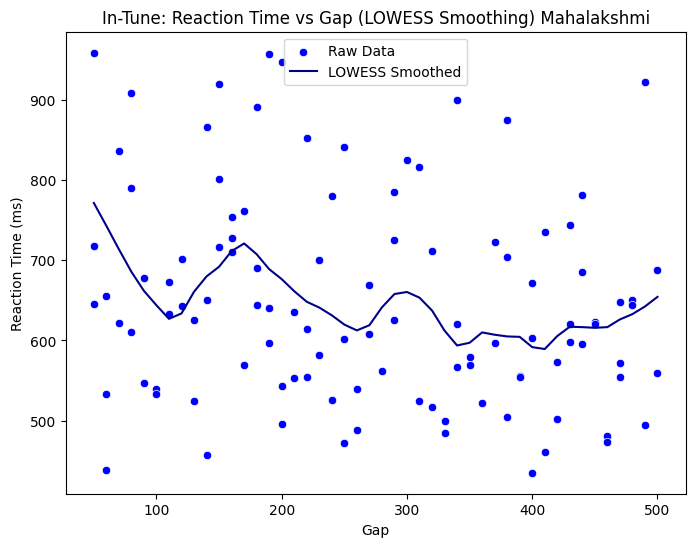

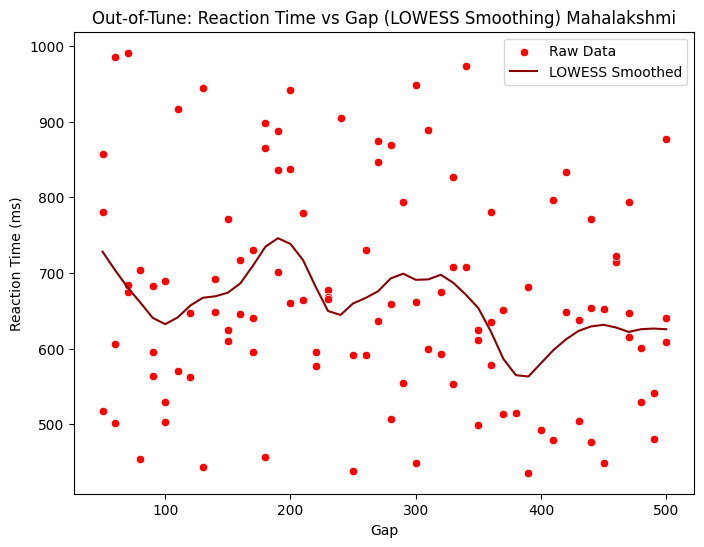

In [ ]:
from statsmodels.nonparametric.smoothers_lowess import lowess

frac = 0.2
maha_smooth_in = lowess(in_tune_df['InAveRT'], in_tune_df['Gap'], frac=frac)
maha_smooth_out = lowess(out_of_tune_df['OutAveRT'], out_of_tune_df['Gap'], frac=frac)

print(maha_smooth_in.shape, maha_smooth_out.shape)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=In['Gap'], y=In['RT'], color='blue', label="Raw Data")
plt.plot(maha_smooth_in[:, 0], maha_smooth_in[:, 1], color='darkblue', linestyle='-', label="LOWESS Smoothed")

str = f"In-Tune: Reaction Time vs Gap (LOWESS Smoothing) {participant_name}"
plt.title(str)
plt.xlabel("Gap")
plt.ylabel("Reaction Time (ms)")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x=Out['Gap'], y=Out['RT'], color='red', label="Raw Data")
plt.plot(maha_smooth_out[:, 0], maha_smooth_out[:, 1], color='darkred', linestyle='-', label="LOWESS Smoothed")

str = f"Out-of-Tune: Reaction Time vs Gap (LOWESS Smoothing) {participant_name}"
plt.title(str)
plt.xlabel("Gap")
plt.ylabel("Reaction Time (ms)")
plt.legend()
plt.show()


In-Tune Mean: 646.5578302573092, In-Tune SD: 42.153606099239546
Out-of-Tune Mean: 658.455054002993, Out-of-Tune SD: 44.43119426547205


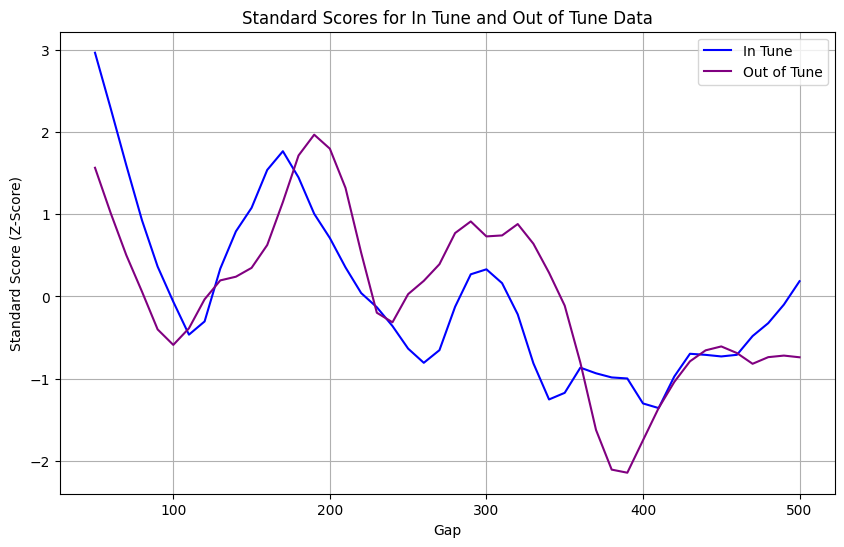

In [ ]:
from statsmodels.nonparametric.smoothers_lowess import lowess

# Apply LOWESS smoothing
frac = 0.2
maha_smooth_in = pd.DataFrame(lowess(in_tune_df['InAveRT'], in_tune_df['Gap'], frac=frac), columns=['Gap', 'InAveRT'])
maha_smooth_out = pd.DataFrame(lowess(out_of_tune_df['OutAveRT'], out_of_tune_df['Gap'], frac=frac), columns=['Gap', 'OutAveRT'])

in_tune_mean = maha_smooth_in['InAveRT'].mean()
in_tune_sd = maha_smooth_in['InAveRT'].std()

out_of_tune_mean = maha_smooth_out['OutAveRT'].mean()
out_of_tune_sd = maha_smooth_out['OutAveRT'].std()

print(f"In-Tune Mean: {in_tune_mean}, In-Tune SD: {in_tune_sd}")
print(f"Out-of-Tune Mean: {out_of_tune_mean}, Out-of-Tune SD: {out_of_tune_sd}")

maha_smooth_in['InAveRT_Z'] = (maha_smooth_in['InAveRT'] - in_tune_mean) / in_tune_sd
maha_smooth_out['OutAveRT_Z'] = (maha_smooth_out['OutAveRT'] - out_of_tune_mean) / out_of_tune_sd

# Plot the standard scores
plt.figure(figsize=(10, 6))
plt.plot(maha_smooth_in['Gap'], maha_smooth_in['InAveRT_Z'], color='blue', label='In Tune')
plt.plot(maha_smooth_out['Gap'], maha_smooth_out['OutAveRT_Z'], color='purple', label='Out of Tune')
plt.xlabel('Gap')
plt.ylabel('Standard Score (Z-Score)')
plt.title('Standard Scores for In Tune and Out of Tune Data')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
file_paths = [
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/addie/addie1.1.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/addie/addie1.2.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/addie/addie1.3.csv"
]
# Check if files exist
for file in file_paths:
    if not os.path.exists(file):
        print(f"Error: {file} does not exist.")
        exit()

participant_name = os.path.basename(os.path.dirname(file_paths[-1])).capitalize()

df = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)

correct_1_M = ((df["Tone"] == 1) & (df["Key"] == "M")).sum()
correct_2_C = ((df["Tone"] == 2) & (df["Key"] == "C")).sum()

total_1_M = (df["Tone"] == 1).sum()
total_2_C = (df["Tone"] == 2).sum()
total_count = len(df)

accuracy_1_M = (correct_1_M / total_1_M) * 100 if total_1_M > 0 else 0
accuracy_2_C = (correct_2_C / total_2_C) * 100 if total_2_C > 0 else 0

correct_count = correct_1_M + correct_2_C
incorrect_count = total_count - correct_count
overall_accuracy = (correct_count / total_count) * 100 if total_count > 0 else 0

print(f"Participant: {participant_name}")
print(f"In-tune correct: {correct_1_M} / {total_1_M} ({accuracy_1_M:.2f}%)")
print(f"Out-of-tune correct: {correct_2_C} / {total_2_C} ({accuracy_2_C:.2f}%)")
print(f"Correct responses: {correct_count}")
print(f"Incorrect responses: {incorrect_count}")
print(f"Overall accuracy: {overall_accuracy:.2f}%")

Participant: Addie
In-tune correct: 110 / 138 (79.71%)
Out-of-tune correct: 107 / 138 (77.54%)
Correct responses: 217
Incorrect responses: 59
Overall accuracy: 78.62%


(46, 2) (46, 2)


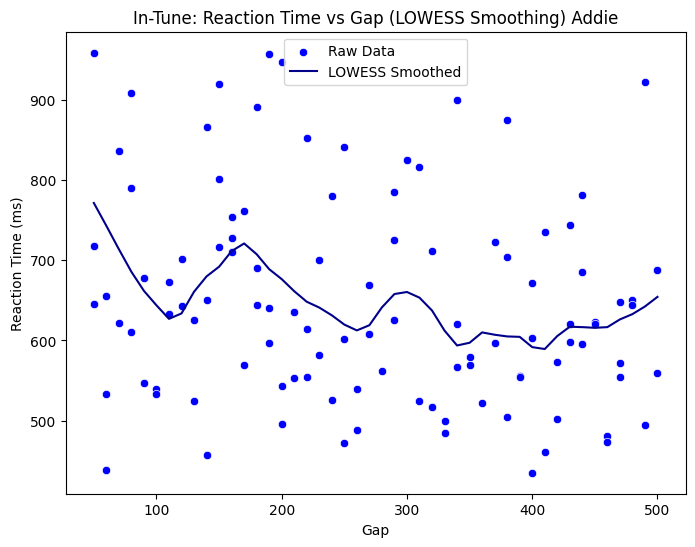

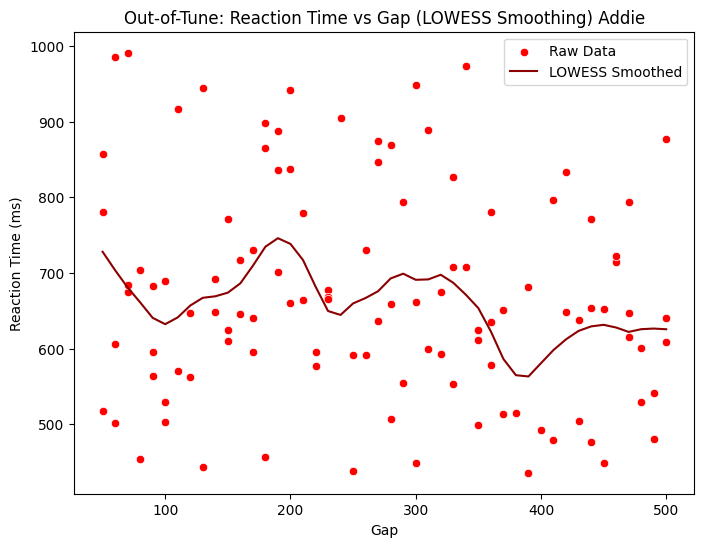

In-Tune Mean: 646.5578302573092, In-Tune SD: 42.153606099239546
Out-of-Tune Mean: 658.455054002993, Out-of-Tune SD: 44.43119426547205


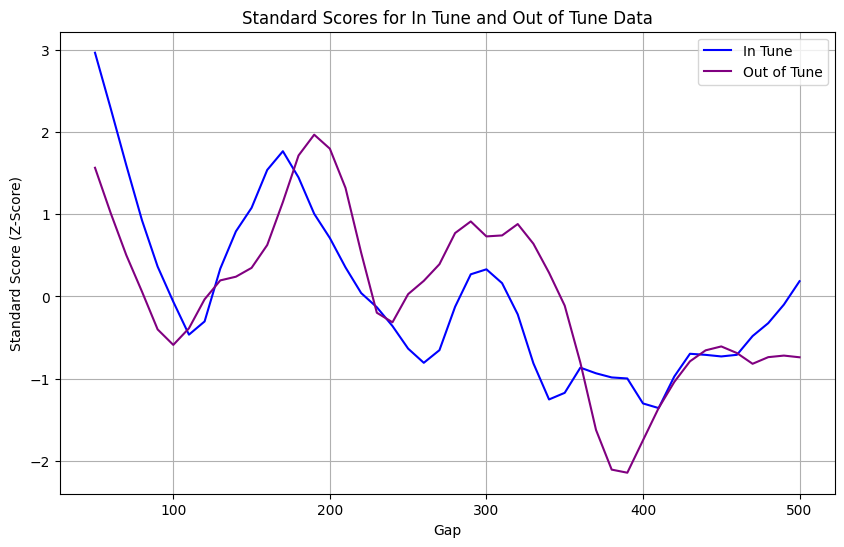

In [ ]:
from statsmodels.nonparametric.smoothers_lowess import lowess

frac = 0.2
addie_smooth_in = lowess(in_tune_df['InAveRT'], in_tune_df['Gap'], frac=frac)
addie_smooth_out = lowess(out_of_tune_df['OutAveRT'], out_of_tune_df['Gap'], frac=frac)

print(addie_smooth_in.shape, addie_smooth_out.shape)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=In['Gap'], y=In['RT'], color='blue', label="Raw Data")
plt.plot(addie_smooth_in[:, 0], addie_smooth_in[:, 1], color='darkblue', linestyle='-', label="LOWESS Smoothed")

str = f"In-Tune: Reaction Time vs Gap (LOWESS Smoothing) {participant_name}"
plt.title(str)
plt.xlabel("Gap")
plt.ylabel("Reaction Time (ms)")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x=Out['Gap'], y=Out['RT'], color='red', label="Raw Data")
plt.plot(addie_smooth_out[:, 0], addie_smooth_out[:, 1], color='darkred', linestyle='-', label="LOWESS Smoothed")

str = f"Out-of-Tune: Reaction Time vs Gap (LOWESS Smoothing) {participant_name}"
plt.title(str)
plt.xlabel("Gap")
plt.ylabel("Reaction Time (ms)")
plt.legend()
plt.show()

from statsmodels.nonparametric.smoothers_lowess import lowess

# Apply LOWESS smoothing
frac = 0.2
addie_smooth_in = pd.DataFrame(lowess(in_tune_df['InAveRT'], in_tune_df['Gap'], frac=frac), columns=['Gap', 'InAveRT'])
addie_smooth_out = pd.DataFrame(lowess(out_of_tune_df['OutAveRT'], out_of_tune_df['Gap'], frac=frac), columns=['Gap', 'OutAveRT'])

in_tune_mean = addie_smooth_in['InAveRT'].mean()
in_tune_sd = addie_smooth_in['InAveRT'].std()

out_of_tune_mean = addie_smooth_out['OutAveRT'].mean()
out_of_tune_sd = addie_smooth_out['OutAveRT'].std()

print(f"In-Tune Mean: {in_tune_mean}, In-Tune SD: {in_tune_sd}")
print(f"Out-of-Tune Mean: {out_of_tune_mean}, Out-of-Tune SD: {out_of_tune_sd}")

addie_smooth_in['InAveRT_Z'] = (addie_smooth_in['InAveRT'] - in_tune_mean) / in_tune_sd
addie_smooth_out['OutAveRT_Z'] = (addie_smooth_out['OutAveRT'] - out_of_tune_mean) / out_of_tune_sd

# Plot the standard scores
plt.figure(figsize=(10, 6))
plt.plot(addie_smooth_in['Gap'], addie_smooth_in['InAveRT_Z'], color='blue', label='In Tune')
plt.plot(addie_smooth_out['Gap'], addie_smooth_out['OutAveRT_Z'], color='purple', label='Out of Tune')
plt.xlabel('Gap')
plt.ylabel('Standard Score (Z-Score)')
plt.title('Standard Scores for In Tune and Out of Tune Data')
plt.legend()
plt.grid(True)
plt.show()



Participant: Angelyn
In-tune correct: 129 / 138 (93.48%)
Out-of-tune correct: 130 / 138 (94.20%)
Correct responses: 259
Incorrect responses: 17
Overall accuracy: 93.84%
(46, 2) (46, 2)


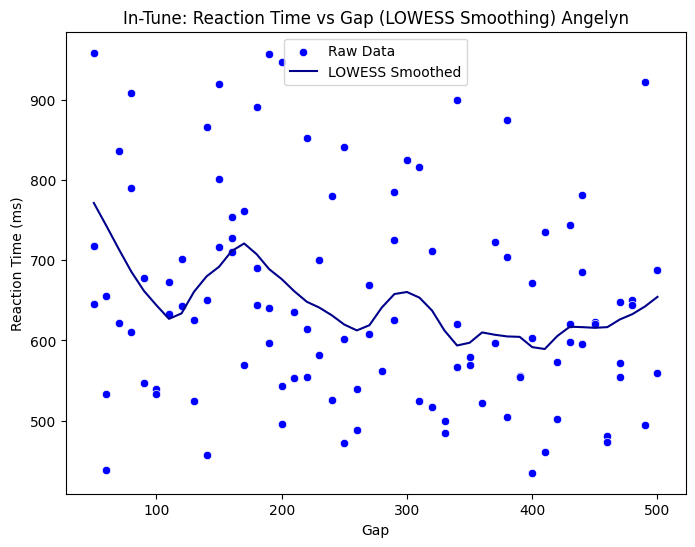

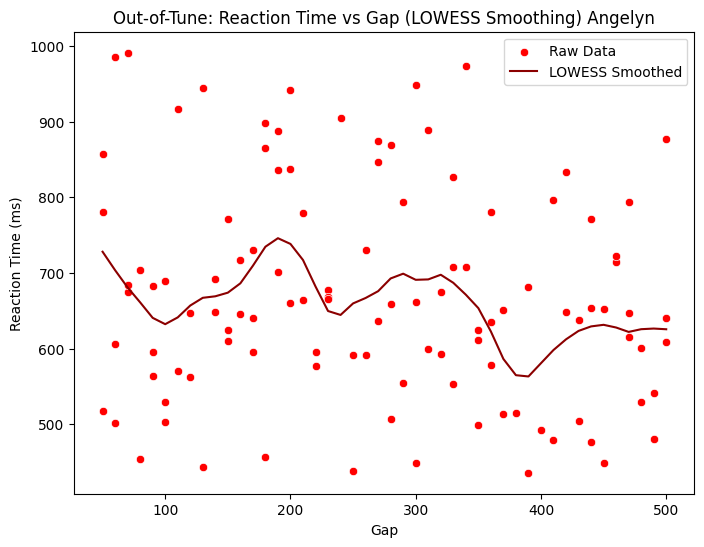

In-Tune Mean: 646.5578302573092, In-Tune SD: 42.153606099239546
Out-of-Tune Mean: 658.455054002993, Out-of-Tune SD: 44.43119426547205


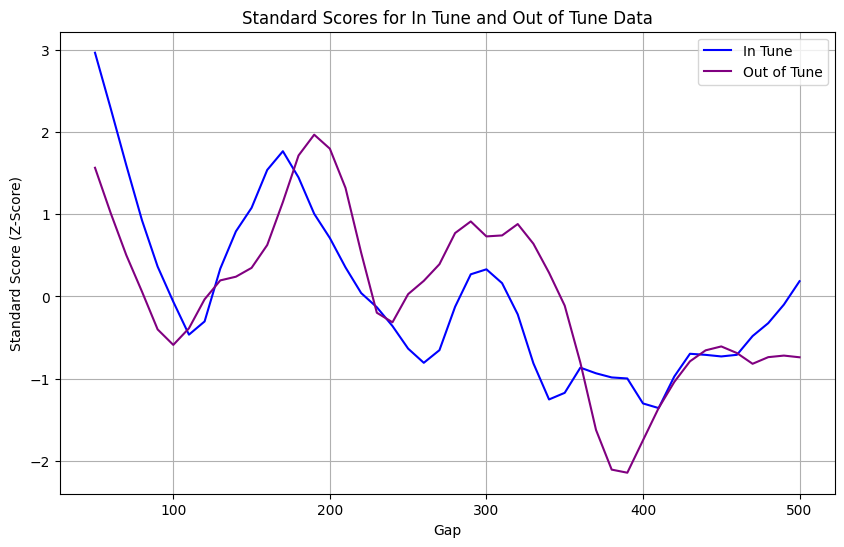

In [ ]:
from statsmodels.nonparametric.smoothers_lowess import lowess

file_paths = [
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/angelyn/angelyn1.1.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/angelyn/angelyn1.2.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/angelyn/angelyn1.3.csv"
]
# Check if files exist
for file in file_paths:
    if not os.path.exists(file):
        print(f"Error: {file} does not exist.")
        exit()

participant_name = os.path.basename(os.path.dirname(file_paths[-1])).capitalize()

df = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)

correct_1_M = ((df["Tone"] == 1) & (df["Key"] == "M")).sum()
correct_2_C = ((df["Tone"] == 2) & (df["Key"] == "C")).sum()

total_1_M = (df["Tone"] == 1).sum()
total_2_C = (df["Tone"] == 2).sum()
total_count = len(df)

accuracy_1_M = (correct_1_M / total_1_M) * 100 if total_1_M > 0 else 0
accuracy_2_C = (correct_2_C / total_2_C) * 100 if total_2_C > 0 else 0

correct_count = correct_1_M + correct_2_C
incorrect_count = total_count - correct_count
overall_accuracy = (correct_count / total_count) * 100 if total_count > 0 else 0

print(f"Participant: {participant_name}")
print(f"In-tune correct: {correct_1_M} / {total_1_M} ({accuracy_1_M:.2f}%)")
print(f"Out-of-tune correct: {correct_2_C} / {total_2_C} ({accuracy_2_C:.2f}%)")
print(f"Correct responses: {correct_count}")
print(f"Incorrect responses: {incorrect_count}")
print(f"Overall accuracy: {overall_accuracy:.2f}%")

frac = 0.2
angelyn_smooth_in = lowess(in_tune_df['InAveRT'], in_tune_df['Gap'], frac=frac)
angelyn_smooth_out = lowess(out_of_tune_df['OutAveRT'], out_of_tune_df['Gap'], frac=frac)

print(angelyn_smooth_in.shape, angelyn_smooth_out.shape)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=In['Gap'], y=In['RT'], color='blue', label="Raw Data")
plt.plot(angelyn_smooth_in[:, 0], angelyn_smooth_in[:, 1], color='darkblue', linestyle='-', label="LOWESS Smoothed")

str = f"In-Tune: Reaction Time vs Gap (LOWESS Smoothing) {participant_name}"
plt.title(str)
plt.xlabel("Gap")
plt.ylabel("Reaction Time (ms)")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x=Out['Gap'], y=Out['RT'], color='red', label="Raw Data")
plt.plot(angelyn_smooth_out[:, 0], angelyn_smooth_out[:, 1], color='darkred', linestyle='-', label="LOWESS Smoothed")

str = f"Out-of-Tune: Reaction Time vs Gap (LOWESS Smoothing) {participant_name}"
plt.title(str)
plt.xlabel("Gap")
plt.ylabel("Reaction Time (ms)")
plt.legend()
plt.show()

# Apply LOWESS smoothing
angelyn_smooth_in = pd.DataFrame(lowess(in_tune_df['InAveRT'], in_tune_df['Gap'], frac=frac), columns=['Gap', 'InAveRT'])
angelyn_smooth_out = pd.DataFrame(lowess(out_of_tune_df['OutAveRT'], out_of_tune_df['Gap'], frac=frac), columns=['Gap', 'OutAveRT'])

in_tune_mean = angelyn_smooth_in['InAveRT'].mean()
in_tune_sd = angelyn_smooth_in['InAveRT'].std()

out_of_tune_mean = angelyn_smooth_out['OutAveRT'].mean()
out_of_tune_sd = angelyn_smooth_out['OutAveRT'].std()

print(f"In-Tune Mean: {in_tune_mean}, In-Tune SD: {in_tune_sd}")
print(f"Out-of-Tune Mean: {out_of_tune_mean}, Out-of-Tune SD: {out_of_tune_sd}")

angelyn_smooth_in['InAveRT_Z'] = (angelyn_smooth_in['InAveRT'] - in_tune_mean) / in_tune_sd
angelyn_smooth_out['OutAveRT_Z'] = (angelyn_smooth_out['OutAveRT'] - out_of_tune_mean) / out_of_tune_sd

# Plot the standard scores
plt.figure(figsize=(10, 6))
plt.plot(angelyn_smooth_in['Gap'], angelyn_smooth_in['InAveRT_Z'], color='blue', label='In Tune')
plt.plot(angelyn_smooth_out['Gap'], angelyn_smooth_out['OutAveRT_Z'], color='purple', label='Out of Tune')
plt.xlabel('Gap')
plt.ylabel('Standard Score (Z-Score)')
plt.title('Standard Scores for In Tune and Out of Tune Data')
plt.legend()
plt.grid(True)
plt.show()


Participant: Lila
In-tune correct: 131 / 138 (94.93%)
Out-of-tune correct: 120 / 138 (86.96%)
Correct responses: 251
Incorrect responses: 25
Overall accuracy: 90.94%
(46, 2) (46, 2)


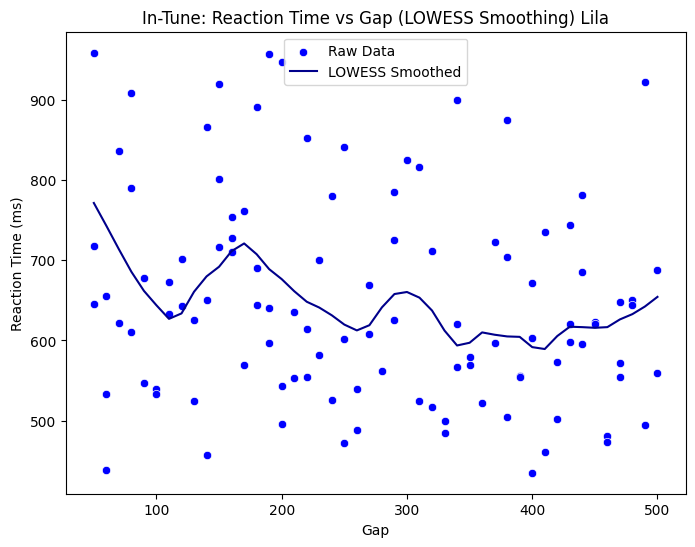

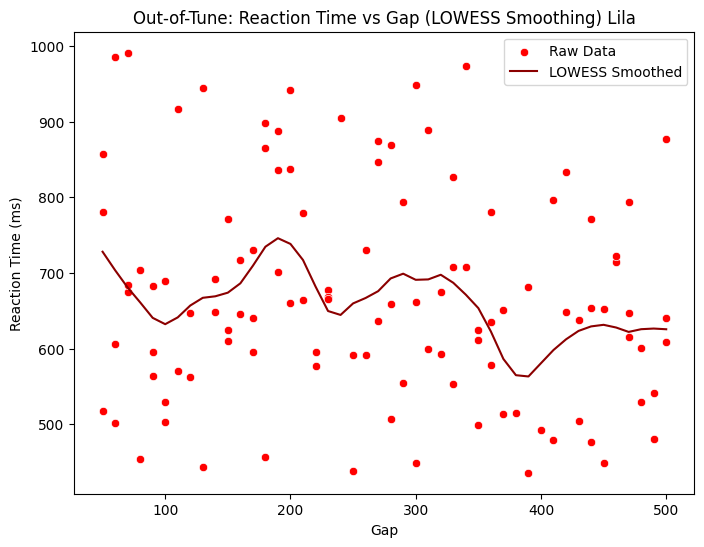

In-Tune Mean: 646.5578302573092, In-Tune SD: 42.153606099239546
Out-of-Tune Mean: 658.455054002993, Out-of-Tune SD: 44.43119426547205


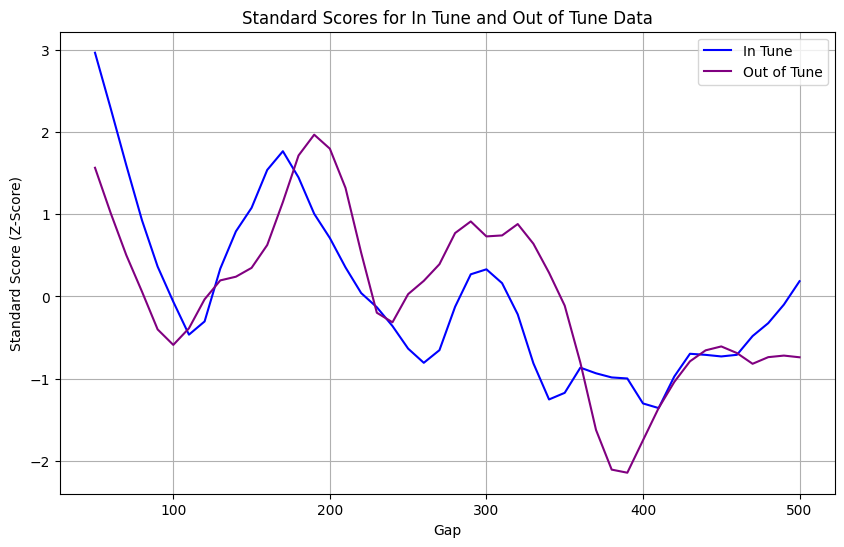

In [ ]:
from statsmodels.nonparametric.smoothers_lowess import lowess

file_paths = [
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/Lila/Lila1.1.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/Lila/Lila1.2.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/Lila/Lila1.3.csv"
]
# Check if files exist
for file in file_paths:
    if not os.path.exists(file):
        print(f"Error: {file} does not exist.")
        exit()

participant_name = os.path.basename(os.path.dirname(file_paths[-1])).capitalize()

df = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)

correct_1_M = ((df["Tone"] == 1) & (df["Key"] == "M")).sum()
correct_2_C = ((df["Tone"] == 2) & (df["Key"] == "C")).sum()

total_1_M = (df["Tone"] == 1).sum()
total_2_C = (df["Tone"] == 2).sum()
total_count = len(df)

accuracy_1_M = (correct_1_M / total_1_M) * 100 if total_1_M > 0 else 0
accuracy_2_C = (correct_2_C / total_2_C) * 100 if total_2_C > 0 else 0

correct_count = correct_1_M + correct_2_C
incorrect_count = total_count - correct_count
overall_accuracy = (correct_count / total_count) * 100 if total_count > 0 else 0

print(f"Participant: {participant_name}")
print(f"In-tune correct: {correct_1_M} / {total_1_M} ({accuracy_1_M:.2f}%)")
print(f"Out-of-tune correct: {correct_2_C} / {total_2_C} ({accuracy_2_C:.2f}%)")
print(f"Correct responses: {correct_count}")
print(f"Incorrect responses: {incorrect_count}")
print(f"Overall accuracy: {overall_accuracy:.2f}%")

frac = 0.2
Lila_smooth_in = lowess(in_tune_df['InAveRT'], in_tune_df['Gap'], frac=frac)
Lila_smooth_out = lowess(out_of_tune_df['OutAveRT'], out_of_tune_df['Gap'], frac=frac)

print(Lila_smooth_in.shape, Lila_smooth_out.shape)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=In['Gap'], y=In['RT'], color='blue', label="Raw Data")
plt.plot(Lila_smooth_in[:, 0], Lila_smooth_in[:, 1], color='darkblue', linestyle='-', label="LOWESS Smoothed")

str = f"In-Tune: Reaction Time vs Gap (LOWESS Smoothing) {participant_name}"
plt.title(str)
plt.xlabel("Gap")
plt.ylabel("Reaction Time (ms)")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x=Out['Gap'], y=Out['RT'], color='red', label="Raw Data")
plt.plot(Lila_smooth_out[:, 0], Lila_smooth_out[:, 1], color='darkred', linestyle='-', label="LOWESS Smoothed")

str = f"Out-of-Tune: Reaction Time vs Gap (LOWESS Smoothing) {participant_name}"
plt.title(str)
plt.xlabel("Gap")
plt.ylabel("Reaction Time (ms)")
plt.legend()
plt.show()

# Apply LOWESS smoothing
Lila_smooth_in = pd.DataFrame(lowess(in_tune_df['InAveRT'], in_tune_df['Gap'], frac=frac), columns=['Gap', 'InAveRT'])
Lila_smooth_out = pd.DataFrame(lowess(out_of_tune_df['OutAveRT'], out_of_tune_df['Gap'], frac=frac), columns=['Gap', 'OutAveRT'])

in_tune_mean = Lila_smooth_in['InAveRT'].mean()
in_tune_sd = Lila_smooth_in['InAveRT'].std()

out_of_tune_mean = Lila_smooth_out['OutAveRT'].mean()
out_of_tune_sd = Lila_smooth_out['OutAveRT'].std()

print(f"In-Tune Mean: {in_tune_mean}, In-Tune SD: {in_tune_sd}")
print(f"Out-of-Tune Mean: {out_of_tune_mean}, Out-of-Tune SD: {out_of_tune_sd}")

Lila_smooth_in['InAveRT_Z'] = (Lila_smooth_in['InAveRT'] - in_tune_mean) / in_tune_sd
Lila_smooth_out['OutAveRT_Z'] = (Lila_smooth_out['OutAveRT'] - out_of_tune_mean) / out_of_tune_sd

# Plot the standard scores
plt.figure(figsize=(10, 6))
plt.plot(Lila_smooth_in['Gap'], Lila_smooth_in['InAveRT_Z'], color='blue', label='In Tune')
plt.plot(Lila_smooth_out['Gap'], Lila_smooth_out['OutAveRT_Z'], color='purple', label='Out of Tune')
plt.xlabel('Gap')
plt.ylabel('Standard Score (Z-Score)')
plt.title('Standard Scores for In Tune and Out of Tune Data')
plt.legend()
plt.grid(True)
plt.show()


Participant: Manaswini
In-tune correct: 97 / 138 (70.29%)
Out-of-tune correct: 81 / 138 (58.70%)
Correct responses: 178
Incorrect responses: 98
Overall accuracy: 64.49%
(46, 2) (46, 2)


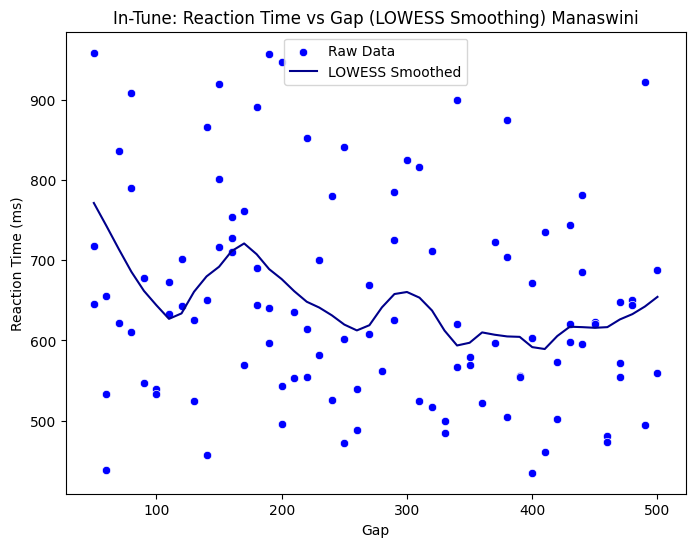

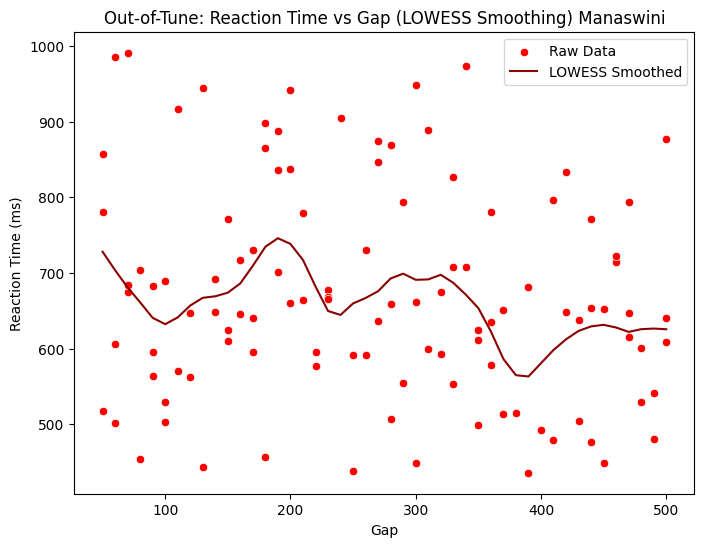

In-Tune Mean: 646.5578302573092, In-Tune SD: 42.153606099239546
Out-of-Tune Mean: 658.455054002993, Out-of-Tune SD: 44.43119426547205


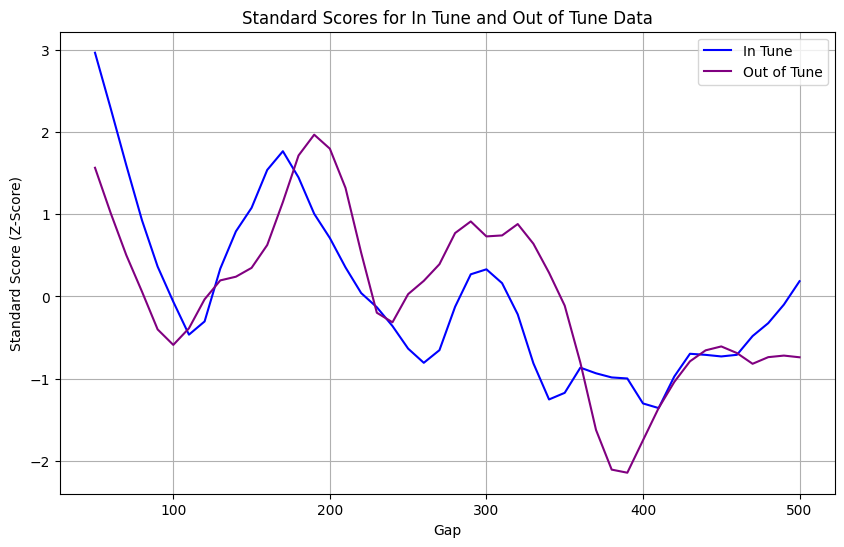

In [ ]:
from statsmodels.nonparametric.smoothers_lowess import lowess

file_paths = [
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/manaswini/Manaswini1.1.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/manaswini/Manaswini1.2.csv",
"/Users/vidhyakshayakannan/Documents/Temporal-Attention/data/manaswini/Manaswini1.3.csv"
]
# Check if files exist
for file in file_paths:
    if not os.path.exists(file):
        print(f"Error: {file} does not exist.")
        exit()

participant_name = os.path.basename(os.path.dirname(file_paths[-1])).capitalize()

df = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)

correct_1_M = ((df["Tone"] == 1) & (df["Key"] == "M")).sum()
correct_2_C = ((df["Tone"] == 2) & (df["Key"] == "C")).sum()

total_1_M = (df["Tone"] == 1).sum()
total_2_C = (df["Tone"] == 2).sum()
total_count = len(df)

accuracy_1_M = (correct_1_M / total_1_M) * 100 if total_1_M > 0 else 0
accuracy_2_C = (correct_2_C / total_2_C) * 100 if total_2_C > 0 else 0

correct_count = correct_1_M + correct_2_C
incorrect_count = total_count - correct_count
overall_accuracy = (correct_count / total_count) * 100 if total_count > 0 else 0

print(f"Participant: {participant_name}")
print(f"In-tune correct: {correct_1_M} / {total_1_M} ({accuracy_1_M:.2f}%)")
print(f"Out-of-tune correct: {correct_2_C} / {total_2_C} ({accuracy_2_C:.2f}%)")
print(f"Correct responses: {correct_count}")
print(f"Incorrect responses: {incorrect_count}")
print(f"Overall accuracy: {overall_accuracy:.2f}%")

frac = 0.2
Manaswini_smooth_in = lowess(in_tune_df['InAveRT'], in_tune_df['Gap'], frac=frac)
Manaswini_smooth_out = lowess(out_of_tune_df['OutAveRT'], out_of_tune_df['Gap'], frac=frac)

print(Manaswini_smooth_in.shape, Manaswini_smooth_out.shape)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=In['Gap'], y=In['RT'], color='blue', label="Raw Data")
plt.plot(Manaswini_smooth_in[:, 0], Manaswini_smooth_in[:, 1], color='darkblue', linestyle='-', label="LOWESS Smoothed")

str = f"In-Tune: Reaction Time vs Gap (LOWESS Smoothing) {participant_name}"
plt.title(str)
plt.xlabel("Gap")
plt.ylabel("Reaction Time (ms)")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x=Out['Gap'], y=Out['RT'], color='red', label="Raw Data")
plt.plot(Manaswini_smooth_out[:, 0], Manaswini_smooth_out[:, 1], color='darkred', linestyle='-', label="LOWESS Smoothed")

str = f"Out-of-Tune: Reaction Time vs Gap (LOWESS Smoothing) {participant_name}"
plt.title(str)
plt.xlabel("Gap")
plt.ylabel("Reaction Time (ms)")
plt.legend()
plt.show()

# Apply LOWESS smoothing
Manaswini_smooth_in = pd.DataFrame(lowess(in_tune_df['InAveRT'], in_tune_df['Gap'], frac=frac), columns=['Gap', 'InAveRT'])
Manaswini_smooth_out = pd.DataFrame(lowess(out_of_tune_df['OutAveRT'], out_of_tune_df['Gap'], frac=frac), columns=['Gap', 'OutAveRT'])

in_tune_mean = Manaswini_smooth_in['InAveRT'].mean()
in_tune_sd = Manaswini_smooth_in['InAveRT'].std()

out_of_tune_mean = Manaswini_smooth_out['OutAveRT'].mean()
out_of_tune_sd = Manaswini_smooth_out['OutAveRT'].std()

print(f"In-Tune Mean: {in_tune_mean}, In-Tune SD: {in_tune_sd}")
print(f"Out-of-Tune Mean: {out_of_tune_mean}, Out-of-Tune SD: {out_of_tune_sd}")

Manaswini_smooth_in['InAveRT_Z'] = (Manaswini_smooth_in['InAveRT'] - in_tune_mean) / in_tune_sd
Manaswini_smooth_out['OutAveRT_Z'] = (Manaswini_smooth_out['OutAveRT'] - out_of_tune_mean) / out_of_tune_sd

# Plot the standard scores
plt.figure(figsize=(10, 6))
plt.plot(Manaswini_smooth_in['Gap'], Manaswini_smooth_in['InAveRT_Z'], color='blue', label='In Tune')
plt.plot(Manaswini_smooth_out['Gap'], Manaswini_smooth_out['OutAveRT_Z'], color='purple', label='Out of Tune')
plt.xlabel('Gap')
plt.ylabel('Standard Score (Z-Score)')
plt.title('Standard Scores for In Tune and Out of Tune Data')
plt.legend()
plt.grid(True)
plt.show()